In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir("/content/drive/MyDrive/DeepCMorph-main")


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88       565
           1       0.79      0.70      0.75       570
           2       0.73      0.88      0.80       565
           3       0.84      0.51      0.63       300

    accuracy                           0.79      2000
   macro avg       0.80      0.76      0.76      2000
weighted avg       0.79      0.79      0.78      2000


Classification Accuracy: 0.788


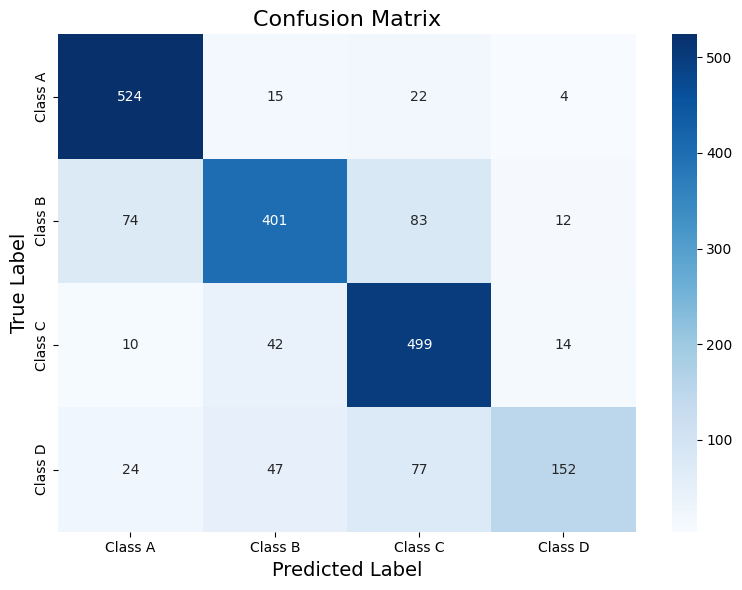

np.float64(0.788)

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report
from timm.models.swin_transformer import swin_base_patch4_window7_224
import timm
import matplotlib.pyplot as plt

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomErasing(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset (without transform)
data_dir = "/content/drive/MyDrive/DeepCMorph-main/data/biomedical/biomedical"
full_dataset = ImageFolder(root=os.path.join(data_dir, "train"))

# Split into train/val
val_ratio = 0.2
val_size = int(val_ratio * len(full_dataset))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Assign transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_test_transform

# Test set
test_dataset = ImageFolder(root=os.path.join(data_dir, "test"), transform=val_test_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

torch.cuda.empty_cache()

# Hybrid Vision Transformer Encoder
class HybridViTEncoder(nn.Module):
    def __init__(self, img_size=256, patch_size=16, embed_dim=768, depth=6, num_heads=8):
        super(HybridViTEncoder, self).__init__()
        self.cnn_backbone = timm.create_model("resnet50", pretrained=True, num_classes=0, global_pool="")
        self.projection = nn.Linear(2048, embed_dim)
        self.vit = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=0)

    def forward(self, x):
        x = self.cnn_backbone(x)
        x = x.flatten(2).transpose(1, 2)
        x = self.projection(x)
        b, n, c = x.shape
        h = w = int(n ** 0.5)
        return x.transpose(1, 2).view(b, c, h, w)

# CNN-based Decoder
class CNNDecoder(nn.Module):
    def __init__(self, embed_dim=768, num_classes=4):
        super(CNNDecoder, self).__init__()
        self.conv1 = nn.Conv2d(embed_dim, 512, kernel_size=3, padding=1)
        self.dropout1 = nn.Dropout(0.3)
        self.conv2 = nn.Conv2d(512, 256, kernel_size=3, padding=1)
        self.dropout2 = nn.Dropout(0.3)
        self.conv3 = nn.Conv2d(256, num_classes, kernel_size=1)
        self.self_attn = nn.MultiheadAttention(embed_dim=num_classes, num_heads=4)
        self.batch_norm = nn.BatchNorm2d(256)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.dropout1(x)
        x = F.relu(self.conv2(x))
        x = self.dropout2(x)
        x = self.batch_norm(x)
        segmentation_map = self.conv3(x)
        b, c, h, w = segmentation_map.shape
        x = segmentation_map.view(b, c, -1).permute(2, 0, 1)
        x, _ = self.self_attn(x, x, x)
        x = x.permute(1, 2, 0).view(b, c, h, w)
        classification_map = torch.argmax(x, dim=1, keepdim=True)
        return segmentation_map, classification_map

# Unified Model
class UnifiedModel(nn.Module):
    def __init__(self, num_classes=4):
        super(UnifiedModel, self).__init__()
        self.segmentation_model = nn.Sequential(HybridViTEncoder(), CNNDecoder())
        self.classification_model = swin_base_patch4_window7_224(pretrained=True, num_classes=num_classes)

    def forward(self, x):
        segmentation_map, _ = self.segmentation_model(x)
        segmentation_map = F.interpolate(segmentation_map, size=(224, 224), mode="bilinear", align_corners=False)
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        combined_input = torch.cat((x, segmentation_map), dim=1)
        combined_input = combined_input[:, :3, :, :]  # Swin expects 3 channels
        classification_output = self.classification_model(combined_input)
        return classification_output

# Initialize model
unified_model = UnifiedModel().to(device)

# Optimizer, Scheduler, Loss
optimizer = torch.optim.Adam(unified_model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = torch.amp.GradScaler(device="cuda")
def compute_segmentation_metrics(preds, targets, num_classes):
    ious = []
    dice_scores = []
    for cls in range(num_classes):
        pred_cls = (preds == cls).astype(np.uint8)
        target_cls = (targets == cls).astype(np.uint8)

        intersection = (pred_cls & target_cls).sum()
        union = (pred_cls | target_cls).sum()
        iou = intersection / (union + 1e-6)
        ious.append(iou)

        dice = (2. * intersection) / (pred_cls.sum() + target_cls.sum() + 1e-6)
        dice_scores.append(dice)
    return ious, dice_scores

# === Training Function with Resume Checkpoint & Logging ===
def train_model(model, dataloader, val_loader, criterion, optimizer, scheduler,
                num_epochs=20, checkpoint_path="unified_checkpoint20.pth", best_model_path="best_model.pth"):
    start_epoch = 0
    best_val_acc = 0
    train_losses, val_accuracies = [], []

    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_acc = checkpoint.get('best_val_acc', 0)
        print(f"Resuming training from epoch {start_epoch}")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device).long()
            optimizer.zero_grad()

            with torch.autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step(epoch + images.size(0) / len(dataloader))

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / len(dataloader)
        train_acc = correct / total
        val_acc = evaluate_model(model, val_loader, silent=True)

        train_losses.append(epoch_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc
        }, checkpoint_path)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"✅ Best model saved with val acc: {val_acc:.4f}")

    # Plot learning curves
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_accuracies, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title('Training Curve')
    plt.legend()
    plt.savefig("training_curve.png")
    plt.close()

# === Evaluate and Save Segmentation Outputs ===
def compute_segmentation_metrics(preds, targets, num_classes):
    ious = []
    dice_scores = []
    for cls in range(num_classes):
        pred_cls = (preds == cls).astype(np.uint8)
        target_cls = (targets == cls).astype(np.uint8)

        intersection = (pred_cls & target_cls).sum()
        union = (pred_cls | target_cls).sum()
        iou = intersection / (union + 1e-6)
        ious.append(iou)

        dice = (2. * intersection) / (pred_cls.sum() + target_cls.sum() + 1e-6)
        dice_scores.append(dice)
    return ious, dice_scores

# === Plotting Functions ===
def plot_segmentation_metrics(ious, dices, class_names=None, save_path="segmentation_metrics.png"):
    import numpy as np
    import matplotlib.pyplot as plt

    num_classes = len(ious)
    x = np.arange(num_classes)
    class_names = class_names or [f"Class {i}" for i in range(num_classes)]

    plt.figure(figsize=(12, 6))
    width = 0.35
    plt.bar(x - width/2, ious, width, label='IoU', color='tab:green')
    plt.bar(x + width/2, dices, width, label='Dice', color='tab:purple')

    plt.xlabel("Classes", fontsize=14)
    plt.ylabel("Score", fontsize=14)
    plt.title("Per-Class IoU and Dice Coefficient", fontsize=16)
    plt.xticks(x, class_names, fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names=None, save_path="confusion_matrix.png"):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_true, y_pred)
    class_names = class_names or [f"Class {i}" for i in range(len(cm))]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix", fontsize=16)
    plt.xlabel("Predicted Label", fontsize=14)
    plt.ylabel("True Label", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
def evaluate_model(model, dataloader, silent=False, save_segmentations=True):
    model.eval()
    all_preds, all_labels = [], []
    all_seg_preds, all_seg_labels = [], []

    with torch.no_grad():
        for i, (images, labels) in enumerate(dataloader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # For segmentation map extraction
            seg_model = model.segmentation_model
            seg_map, cls_map = seg_model(images)
            seg_preds = torch.argmax(seg_map, dim=1)
            all_seg_preds.append(seg_preds.cpu().numpy())
            all_seg_labels.append(labels.cpu().numpy())

            # if save_segmentations:
            #     os.makedirs("seg_outputs", exist_ok=True)
            #     for j in range(images.size(0)):
            #         plt.imsave(f"seg_outputs/sample_{i}_{j}.png", seg_preds[j].cpu().numpy())

    if not silent:
        print("Classification Report:")
        print(classification_report(all_labels, all_preds))

    cls_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    seg_preds_np = np.concatenate(all_seg_preds)
    seg_labels_np = np.concatenate(all_seg_labels)
    #ious, dices = compute_segmentation_metrics(seg_preds_np, seg_labels_np, num_classes=4)

    print("\nClassification Accuracy:", cls_acc)
    #print("Mean IoU:", np.mean(ious))
    #print("Mean Dice Coefficient:", np.mean(dices))

    plot_confusion_matrix(all_labels, all_preds, class_names=["Class A", "Class B", "Class C", "Class D"])
   # plot_segmentation_metrics(ious, dices, class_names=["Background", "Class A", "Class B", "Class C"])

    return cls_acc

# === Run training and evaluation ===
#train_model(unified_model, train_loader, val_loader, criterion, optimizer, scheduler)
unified_model.load_state_dict(torch.load("best_model.pth"))
evaluate_model(unified_model, test_loader)

# # Training function
# def train_model(model, dataloader, val_loader, criterion, optimizer, scheduler, num_epochs=50, checkpoint_path="best_model.pth"):
#     best_val_acc = 0

#     for epoch in range(num_epochs):
#         model.train()
#         running_loss, correct, total = 0.0, 0, 0
#         for images, labels in dataloader:
#             images, labels = images.to(device), labels.to(device).long()
#             optimizer.zero_grad()

#             with torch.autocast(device_type="cuda"):
#                 outputs = model(images)
#                 loss = criterion(outputs, labels)

#             scaler.scale(loss).backward()
#             scaler.step(optimizer)
#             scaler.update()
#             scheduler.step(epoch + images.size(0) / len(dataloader))

#             running_loss += loss.item()
#             _, preds = torch.max(outputs, 1)
#             correct += (preds == labels).sum().item()
#             total += labels.size(0)

#         accuracy = correct / total
#         print(f"Epoch {epoch+1}, Train Loss: {running_loss/len(dataloader):.4f}, Train Acc: {accuracy:.4f}")

#         # Validation
#         val_acc = evaluate_model(model, val_loader, silent=True)
#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             torch.save(model.state_dict(), checkpoint_path)
#             print(f"✅ Best model updated at epoch {epoch+1} with val acc: {val_acc:.4f}")

# def evaluate_model(model, dataloader, silent=False):
#     model.eval()
#     all_preds, all_labels = [], []
#     with torch.no_grad():
#         for images, labels in dataloader:
#             images, labels = images.to(device), labels.to(device)
#             outputs = model(images)
#             _, preds = torch.max(outputs, 1)
#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())
#     if not silent:
#         print("Final Classification Report:")
#         print(classification_report(all_labels, all_preds))
#     accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
#     return accuracy

# # Train and Evaluate
# train_model(unified_model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=50)
# unified_model.load_state_dict(torch.load("best_model.pth"))
# evaluate_model(unified_model, test_loader)


In [ ]:
# Restart the runtime first (via Runtime > Restart runtime in the menu), then run:
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install timm --upgrade
!pip install --upgrade transformers


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report
from timm.models.swin_transformer import swin_base_patch4_window7_224
import timm
import matplotlib.pyplot as plt

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data transformations with stronger augmentation
transform = transforms.Compose([
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),  # Moved before RandomErasing
    transforms.RandomErasing(p=0.2),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
data_dir = "/content/drive/MyDrive/DeepCMorph-main/data/biomedical/biomedical"
full_dataset = ImageFolder(root=os.path.join(data_dir, "train"), transform=transform)
test_dataset = ImageFolder(root=os.path.join(data_dir, "test"), transform=transform)

# Split train into train/val
val_ratio = 0.2
val_size = int(val_ratio * len(full_dataset))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

torch.cuda.empty_cache()

# Hybrid Vision Transformer Encoder
class HybridViTEncoder(nn.Module):
    def __init__(self, img_size=256, patch_size=16, embed_dim=768, depth=6, num_heads=8):
        super(HybridViTEncoder, self).__init__()
        self.cnn_backbone = timm.create_model("resnet50", pretrained=True, num_classes=0, global_pool="")
        self.projection = nn.Linear(2048, embed_dim)
        self.vit = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=0)

    def forward(self, x):
        x = self.cnn_backbone(x)
        x = x.flatten(2).transpose(1, 2)
        x = self.projection(x)
        b, n, c = x.shape
        h = w = int(n ** 0.5)
        return x.transpose(1, 2).view(b, c, h, w)

# CNN-based Decoder with Dropout & Attention Layer
class CNNDecoder(nn.Module):
    def __init__(self, embed_dim=768, num_classes=4):
        super(CNNDecoder, self).__init__()
        self.conv1 = nn.Conv2d(embed_dim, 512, kernel_size=3, padding=1)
        self.dropout1 = nn.Dropout(0.3)
        self.conv2 = nn.Conv2d(512, 256, kernel_size=3, padding=1)
        self.dropout2 = nn.Dropout(0.3)
        self.conv3 = nn.Conv2d(256, num_classes, kernel_size=1)
        self.self_attn = nn.MultiheadAttention(embed_dim=num_classes, num_heads=4)
        self.batch_norm = nn.BatchNorm2d(256)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.dropout1(x)
        x = F.relu(self.conv2(x))
        x = self.dropout2(x)
        x = self.batch_norm(x)
        segmentation_map = self.conv3(x)
        b, c, h, w = segmentation_map.shape
        x = segmentation_map.view(b, c, -1).permute(2, 0, 1)
        x, _ = self.self_attn(x, x, x)
        x = x.permute(1, 2, 0).view(b, c, h, w)
        classification_map = torch.argmax(x, dim=1, keepdim=True)
        return segmentation_map, classification_map

# Unified Model with Swin Transformer Classifier
class UnifiedModel(nn.Module):
    def __init__(self, num_classes=4):
        super(UnifiedModel, self).__init__()
        self.segmentation_model = nn.Sequential(HybridViTEncoder(), CNNDecoder())
        self.classification_model = swin_base_patch4_window7_224(pretrained=True, num_classes=num_classes)

    def forward(self, x):
        segmentation_map, _ = self.segmentation_model(x)
        segmentation_map = F.interpolate(segmentation_map, size=(224, 224), mode="bilinear", align_corners=False)
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        combined_input = torch.cat((x, segmentation_map), dim=1)
        combined_input = combined_input[:, :3, :, :]  # Swin only accepts 3-channel input
        classification_output = self.classification_model(combined_input)
        return classification_output

# Initialize Model
unified_model = UnifiedModel().to(device)

# Optimizer, Scheduler, Loss
optimizer = torch.optim.Adam(unified_model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = torch.amp.GradScaler()

# Training Function

def train_model(model, dataloader, val_loader, criterion, optimizer, scheduler, num_epochs=25, checkpoint_path="unified_checkpoint6.pth"):
    start_epoch = 0
    best_val_acc = 0
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming training from epoch {start_epoch}")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device).long()
            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        accuracy = correct / total
        print(f"Epoch {epoch+1}, Train Loss: {running_loss/len(dataloader):.4f}, Train Acc: {accuracy:.4f}")

        # Validation
        val_acc = evaluate_model(model, val_loader, silent=True)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict()}, checkpoint_path)
            print(f"Best model updated at epoch {epoch+1} with val acc: {val_acc:.4f}")

def evaluate_model(model, dataloader, silent=False):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    if not silent:
        print("Final Classification Report:")
        print(classification_report(all_labels, all_preds))
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    return accuracy

# Train and Evaluate
train_model(unified_model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=25)
evaluate_model(unified_model, test_loader)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Resuming training from epoch 14


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report
from timm.models.vision_transformer import VisionTransformer
import timm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data transformations with augmentation
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
data_dir = "/content/drive/MyDrive/DeepCMorph-main/data/biomedical/biomedical"
train_dataset = ImageFolder(root=os.path.join(data_dir, "train"), transform=transform)
test_dataset = ImageFolder(root=os.path.join(data_dir, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

torch.cuda.empty_cache()

# Hybrid Vision Transformer Encoder
class HybridViTEncoder(nn.Module):
    def __init__(self, img_size=256, patch_size=16, embed_dim=768, depth=6, num_heads=8):
        super(HybridViTEncoder, self).__init__()

        # CNN Backbone (ResNet-50 without classification head)
        self.cnn_backbone = timm.create_model("resnet50", pretrained=True, num_classes=0, global_pool="")

        # Linear Projection to match ViT embed_dim
        self.projection = nn.Linear(2048, embed_dim)

        # Vision Transformer
        self.vit = VisionTransformer(
            img_size=img_size // 4,  # Adjusted for CNN downscaling
            patch_size=patch_size,
            in_chans=embed_dim,  # Adjusted input channels
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            num_classes=0
        )

    def forward(self, x):
        # Extract features using ResNet-50
        x = self.cnn_backbone(x)  # Shape: (B, 2048, H/32, W/32)

        # Reshape for ViT processing
        x = x.flatten(2).transpose(1, 2)  # Shape: (B, Num_Patches, 2048)
        x = self.projection(x)  # Shape: (B, Num_Patches, embed_dim)

        # Pass through ViT
        x = self.vit.blocks(x)

        # Reshape to feature map
        b, n, c = x.shape
        h = w = int(n ** 0.5)
        return x.transpose(1, 2).view(b, c, h, w)  # Shape: (B, C, H, W)

# CNN-based Decoder with Attention Layer
class CNNDecoder(nn.Module):
    def __init__(self, embed_dim=768, num_classes=4):
        super(CNNDecoder, self).__init__()
        self.conv1 = nn.Conv2d(embed_dim, 512, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(512, 256, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(256, num_classes, kernel_size=1)
        self.self_attn = nn.MultiheadAttention(embed_dim=num_classes, num_heads=4)
        self.batch_norm = nn.BatchNorm2d(256)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.batch_norm(x)
        segmentation_map = self.conv3(x)
        b, c, h, w = segmentation_map.shape
        x = segmentation_map.view(b, c, -1).permute(2, 0, 1)
        x, _ = self.self_attn(x, x, x)
        x = x.permute(1, 2, 0).view(b, c, h, w)
        classification_map = torch.argmax(x, dim=1, keepdim=True)
        return segmentation_map, classification_map

# Unified Model with Hybrid ViT Classifier
class UnifiedModel(nn.Module):
    def __init__(self, num_classes=4):
        super(UnifiedModel, self).__init__()
        self.segmentation_model = nn.Sequential(HybridViTEncoder(), CNNDecoder())
        self.classification_model = VisionTransformer(
            img_size=256, patch_size=8, in_chans=3 + num_classes,
            embed_dim=768, depth=6, num_heads=8, num_classes=num_classes,
            drop_rate=0.2
        )

    def forward(self, x):
        segmentation_map, _ = self.segmentation_model(x)
        segmentation_map = F.interpolate(segmentation_map, size=(256, 256), mode="bilinear", align_corners=False)
        combined_input = torch.cat((x, segmentation_map), dim=1)
        classification_output = self.classification_model(combined_input)
        return classification_output

# Initialize Model
unified_model = UnifiedModel().to(device)

# Optimizer and Loss
optimizer = torch.optim.Adam(unified_model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = torch.amp.GradScaler()

# Training Function
def train_model(model, dataloader, criterion, optimizer, scheduler, num_epochs=35, checkpoint_path="unified_checkpoint5.pth"):
    start_epoch = 0
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming training from epoch {start_epoch}")

    model.train()
    for epoch in range(start_epoch, num_epochs):
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device).long()
            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        accuracy = correct / total
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(dataloader):.4f}, Accuracy: {accuracy:.4f}")
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict()}, checkpoint_path)
def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    print("Final Classification Report:")
    print(classification_report(all_labels, all_preds))
# Train and Evaluate the Model
train_model(unified_model, train_loader, criterion, optimizer, scheduler, num_epochs=35)
evaluate_model(unified_model, test_loader)


Resuming training from epoch 30


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 31, Loss: 0.5926, Accuracy: 0.8793
Epoch 32, Loss: 0.5825, Accuracy: 0.8843
Epoch 33, Loss: 0.5779, Accuracy: 0.8867
Epoch 34, Loss: 0.5739, Accuracy: 0.8879
Epoch 35, Loss: 0.5664, Accuracy: 0.8922
Final Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       565
           1       0.78      0.69      0.73       570
           2       0.69      0.87      0.77       565
           3       0.80      0.47      0.60       300

    accuracy                           0.77      2000
   macro avg       0.78      0.73      0.74      2000
weighted avg       0.78      0.77      0.76      2000



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report
from timm.models.vision_transformer import VisionTransformer
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data transformations with standard normalization
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
data_dir = "/content/drive/MyDrive/DeepCMorph-main/data/biomedical/biomedical"
train_dataset = ImageFolder(root=os.path.join(data_dir, "train"), transform=transform)
test_dataset = ImageFolder(root=os.path.join(data_dir, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

torch.cuda.empty_cache()

# Vision Transformer Encoder with fixed output shape
class ViTEncoder(nn.Module):
    def __init__(self, img_size=256, patch_size=16, embed_dim=768, depth=6, num_heads=8):
        super(ViTEncoder, self).__init__()
        self.vit = VisionTransformer(
            img_size=img_size, patch_size=patch_size, in_chans=3,
            embed_dim=embed_dim, depth=depth, num_heads=num_heads, num_classes=0
        )

    def forward(self, x):
        x = self.vit.patch_embed(x)
        x = self.vit.pos_drop(x)
        for blk in self.vit.blocks:
            x = blk(x)
        b, n, c = x.shape  # Ensure expected dimensions
        h = w = int(n ** 0.5)  # Infer spatial size
        return x.transpose(1, 2).view(b, c, h, w)

# CNN-based Decoder with Attention Layer
class CNNDecoder(nn.Module):
    def __init__(self, embed_dim=768, num_classes=4):
        super(CNNDecoder, self).__init__()
        self.conv1 = nn.Conv2d(embed_dim, 256, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(256, num_classes, kernel_size=1)
        self.attn = nn.MultiheadAttention(embed_dim=num_classes, num_heads=2)  # Adjusted embed_dim and num_heads

    def forward(self, x):
        x = F.relu(self.conv1(x))
        segmentation_map = self.conv2(x)
        b, c, h, w = segmentation_map.shape
        x = segmentation_map.view(b, c, -1).permute(2, 0, 1)
        x, _ = self.attn(x, x, x)
        x = x.permute(1, 2, 0).view(b, c, h, w)
        classification_map = torch.argmax(x, dim=1, keepdim=True)
        return segmentation_map, classification_map

# Unified Model with ViT Classifier
class UnifiedModel(nn.Module):
    def __init__(self, num_classes=4):
        super(UnifiedModel, self).__init__()
        self.segmentation_model = nn.Sequential(ViTEncoder(), CNNDecoder())
        self.classification_model = VisionTransformer(
            img_size=256, patch_size=16, in_chans=3 + num_classes,
            embed_dim=768, depth=6, num_heads=8, num_classes=num_classes
        )

    def forward(self, x):
        segmentation_map, _ = self.segmentation_model(x)
        segmentation_map = F.interpolate(segmentation_map, size=(256, 256), mode="bilinear", align_corners=False)
        combined_input = torch.cat((x, segmentation_map), dim=1)
        classification_output = self.classification_model(combined_input)
        return classification_output

# Initialize Model
unified_model = UnifiedModel().to(device)

# Optimizer and Loss
optimizer = torch.optim.Adam(unified_model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

# Mixed Precision Training
scaler = torch.amp.GradScaler()

# Training Function
def train_model(model, dataloader, criterion, optimizer, num_epochs=10, checkpoint_path="unified_checkpoint2.pth"):
    start_epoch = 0
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming training from epoch {start_epoch}")

    model.train()
    for epoch in range(start_epoch, num_epochs):
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device).long()
            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):  # Enables mixed precision
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        accuracy = correct / total
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(dataloader):.4f}, Accuracy: {accuracy:.4f}")
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict()}, checkpoint_path)

# Evaluation Function
def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    print("Final Classification Report:")
    print(classification_report(all_labels, all_preds))

# Train and Evaluate the Model
train_model(unified_model, train_loader, criterion, optimizer, num_epochs=10)
evaluate_model(unified_model, test_loader)


Epoch 1, Loss: 1.1007, Accuracy: 0.5200
Epoch 2, Loss: 0.8587, Accuracy: 0.6595
Epoch 3, Loss: 0.8101, Accuracy: 0.6797
Epoch 4, Loss: 0.7861, Accuracy: 0.6912
Epoch 5, Loss: 0.7612, Accuracy: 0.6989
Epoch 6, Loss: 0.7447, Accuracy: 0.7081
Epoch 7, Loss: 0.7287, Accuracy: 0.7140
Epoch 8, Loss: 0.7149, Accuracy: 0.7206
Epoch 9, Loss: 0.7119, Accuracy: 0.7217
Epoch 10, Loss: 0.6963, Accuracy: 0.7301
Final Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       565
           1       0.69      0.65      0.67       570
           2       0.61      0.88      0.72       565
           3       0.83      0.28      0.42       300

    accuracy                           0.71      2000
   macro avg       0.75      0.66      0.66      2000
weighted avg       0.74      0.71      0.69      2000



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report
from timm.models.vision_transformer import VisionTransformer
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data transformations with standard normalization
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
data_dir = "/content/drive/MyDrive/DeepCMorph-main/data/biomedical/biomedical"
train_dataset = ImageFolder(root=os.path.join(data_dir, "train"), transform=transform)
test_dataset = ImageFolder(root=os.path.join(data_dir, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

torch.cuda.empty_cache()

# Vision Transformer Encoder with pretrained weights
class ViTEncoder(nn.Module):
    def __init__(self, img_size=256, patch_size=8, embed_dim=768, depth=6, num_heads=8):
        super(ViTEncoder, self).__init__()
        self.vit = VisionTransformer(
            img_size=img_size, patch_size=patch_size, in_chans=3,
            embed_dim=embed_dim, depth=depth, num_heads=num_heads, num_classes=0
        )

    def forward(self, x):
        x = self.vit.patch_embed(x)
        x = self.vit.pos_drop(x)
        for blk in self.vit.blocks:
            x = blk(x)
        batch_size, num_patches, embed_dim = x.shape  # Debug shape
        side_length = int(num_patches ** 0.5)  # Ensure correct reshaping
        return x.transpose(1, 2).view(batch_size, embed_dim, side_length, side_length)

# CNN-based Decoder with improved architecture
class CNNDecoder(nn.Module):
    def __init__(self, embed_dim=768, num_classes=4):
        super(CNNDecoder, self).__init__()
        self.conv1 = nn.Conv2d(embed_dim, 256, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, num_classes, kernel_size=3, padding=1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        segmentation_map = self.conv3(x)
        classification_map = torch.argmax(segmentation_map, dim=1, keepdim=True)
        return segmentation_map, classification_map

# Unified Model with ViT Classifier
class UnifiedModel(nn.Module):
    def __init__(self, num_classes=4):
        super(UnifiedModel, self).__init__()
        self.segmentation_model = nn.Sequential(ViTEncoder(), CNNDecoder())
        self.classification_model = VisionTransformer(
            img_size=256, patch_size=8, in_chans=3 + num_classes,
            embed_dim=768, depth=6, num_heads=8, num_classes=num_classes
        )

    def forward(self, x):
        segmentation_map, _ = self.segmentation_model(x)
        segmentation_map = F.interpolate(segmentation_map, size=(256, 256), mode="bilinear", align_corners=False)
        combined_input = torch.cat((x, segmentation_map), dim=1)
        classification_output = self.classification_model(combined_input)
        return classification_output

# Initialize Model
unified_model = UnifiedModel().to(device)

# Optimizer and Loss
optimizer = torch.optim.Adam(unified_model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

# Mixed Precision Training
scaler = torch.cuda.amp.GradScaler()

# Training Function
def train_model(model, dataloader, criterion, optimizer, num_epochs=10, checkpoint_path="unified_checkpoint.pth"):
    start_epoch = 0
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming training from epoch {start_epoch}")

    model.train()
    for epoch in range(start_epoch, num_epochs):
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device).long()
            optimizer.zero_grad()

            with torch.cuda.amp.autocast():  # Enables mixed precision
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        accuracy = correct / total
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(dataloader):.4f}, Accuracy: {accuracy:.4f}")
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict()}, checkpoint_path)

# Evaluation Function
def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    print("Final Classification Report:")
    print(classification_report(all_labels, all_preds))

# Train and Evaluate the Model
train_model(unified_model, train_loader, criterion, optimizer, num_epochs=10)
evaluate_model(unified_model, test_loader)


<ipython-input-3-f01c20cca20b>:90: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Resuming training from epoch 6


<ipython-input-3-f01c20cca20b>:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # Enables mixed precision


Epoch 7, Loss: 0.7100, Accuracy: 0.7223
Epoch 8, Loss: 0.7002, Accuracy: 0.7279
Epoch 9, Loss: 0.6879, Accuracy: 0.7343
Epoch 10, Loss: 0.6911, Accuracy: 0.7323
Final Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       565
           1       0.71      0.56      0.62       570
           2       0.68      0.74      0.71       565
           3       0.60      0.63      0.61       300

    accuracy                           0.70      2000
   macro avg       0.69      0.69      0.69      2000
weighted avg       0.70      0.70      0.70      2000



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from timm.models.vision_transformer import VisionTransformer

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load dataset
data_dir = "/content/drive/MyDrive/DeepCMorph-main/data/biomedical/biomedical"
train_dataset = ImageFolder(root=os.path.join(data_dir, "train"), transform=transform)
test_dataset = ImageFolder(root=os.path.join(data_dir, "test"), transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# Vision Transformer Encoder
class ViTEncoder(nn.Module):
    def __init__(self, img_size=256, patch_size=16, in_chans=3, embed_dim=768, depth=6, num_heads=8):
        super(ViTEncoder, self).__init__()
        self.vit = VisionTransformer(img_size=img_size, patch_size=patch_size, in_chans=in_chans,
                                     embed_dim=embed_dim, depth=depth, num_heads=num_heads, num_classes=0)

    def forward(self, x):
        x = self.vit.patch_embed(x)  # Extract patch embeddings
        x = self.vit.pos_drop(x)     # Apply positional embeddings
        for blk in self.vit.blocks:
            x = blk(x)               # Pass through transformer blocks
        return x.transpose(1, 2).view(x.shape[0], 768, 16, 16)  # Reshape for CNN Decoder

# CNN-based Decoder with Attention Layers
class CNNDecoder(nn.Module):
    def __init__(self, embed_dim=768, num_classes=4):
        super(CNNDecoder, self).__init__()
        self.conv1 = nn.ConvTranspose2d(embed_dim, 128, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.ConvTranspose2d(128, num_classes, kernel_size=3, stride=1, padding=1)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads=8)

    def forward(self, x):
        x = x.flatten(2).permute(2, 0, 1)  # Flatten spatial dimensions and permute
        x, _ = self.attn(x, x, x)
        x = x.permute(1, 2, 0).view(x.shape[1], 768, 16, 16)  # Reshape to match image dimensions
        x = F.relu(self.conv1(x))
        x = self.conv2(x)
        return x

# Segmentation Model
class SegmentationModel(nn.Module):
    def __init__(self):
        super(SegmentationModel, self).__init__()
        self.encoder = ViTEncoder()
        self.decoder = CNNDecoder()

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

seg_model = SegmentationModel().to(device)

# Classification Model (Vision Transformer)
class ClassificationModel(nn.Module):
    def __init__(self, num_classes=4):
        super(ClassificationModel, self).__init__()
        self.vit = VisionTransformer(img_size=256, patch_size=16, in_chans=3, embed_dim=768, depth=6, num_heads=8, num_classes=num_classes)

    def forward(self, x):
        return self.vit(x)

clf_model = ClassificationModel(num_classes=4).to(device)

# Training function with checkpoints
def train_model(model, dataloader, criterion, optimizer, num_epochs=10, checkpoint_path="checkpoint.pth"):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device).long()
            optimizer.zero_grad()
            outputs = model(images)
            if outputs.dim() == 4:  # If segmentation output
                 labels = labels.view(labels.shape[0], 1, 1).expand(-1, outputs.shape[2], outputs.shape[3])
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.numel()
        accuracy = correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(dataloader):.4f}, Accuracy: {accuracy:.4f}")
        torch.save(model.state_dict(), checkpoint_path)

# Function to calculate evaluation metrics
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device).long()
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.view(-1).cpu().numpy())
            all_labels.extend(labels.view(-1).cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)

# Train segmentation model
seg_optimizer = torch.optim.Adam(seg_model.parameters(), lr=0.001)
seg_criterion = nn.CrossEntropyLoss()
train_model(seg_model, train_loader, seg_criterion, seg_optimizer, num_epochs=10, checkpoint_path="segmentation_checkpoint.pth")
# Train classification model
clf_optimizer = torch.optim.Adam(clf_model.parameters(), lr=0.001)
clf_criterion = nn.CrossEntropyLoss()
train_model(clf_model, train_loader, clf_criterion, clf_optimizer, num_epochs=10, checkpoint_path="classification_checkpoint.pth")
# Evaluate models
evaluate_model(seg_model, test_loader)
evaluate_model(clf_model, test_loader)
print("Pipeline complete!")


Epoch 1/10, Loss: 2.1798, Accuracy: 0.3322
Epoch 2/10, Loss: 1.2906, Accuracy: 0.3501
Epoch 3/10, Loss: 1.2881, Accuracy: 0.3501
Epoch 4/10, Loss: 1.2879, Accuracy: 0.3501
Epoch 5/10, Loss: 1.2881, Accuracy: 0.3501
Epoch 6/10, Loss: 1.2880, Accuracy: 0.3501
Epoch 7/10, Loss: 1.2880, Accuracy: 0.3501
Epoch 8/10, Loss: 1.2880, Accuracy: 0.3501
Epoch 9/10, Loss: 1.2879, Accuracy: 0.3501
Epoch 10/10, Loss: 1.2880, Accuracy: 0.3501
Epoch 1/10, Loss: 1.2278, Accuracy: 0.4609
Epoch 2/10, Loss: 1.1994, Accuracy: 0.4526
Epoch 3/10, Loss: 1.1918, Accuracy: 0.4621
Epoch 4/10, Loss: 1.1651, Accuracy: 0.4801


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import swin_t, Swin_T_Weights
from torchvision.models.feature_extraction import create_feature_extractor

class UpsampleConvLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=2):
        super(UpsampleConvLayer, self).__init__()
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride)
        self.relu = nn.LeakyReLU(0.2)

    def forward(self, x):
        out = self.upconv(x)
        out = self.relu(out)
        return out

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.conv(x)

class DeepCMorphSegmentationModule(nn.Module):
    def __init__(self, use_skips=False, num_classes=7):
        super(DeepCMorphSegmentationModule, self).__init__()
        net = swin_t(weights=Swin_T_Weights.DEFAULT)

        self.return_nodes = {
            "features.2": "f1",
            "features.3": "f2",
            "features.4": "f3",
            "features.5": "f4"
        }
        self.encoder = create_feature_extractor(net, return_nodes=self.return_nodes)
        for p in self.encoder.parameters():
            p.requires_grad = True

        self.upsample_1 = UpsampleConvLayer(768, 512, 2)
        self.upsample_2 = UpsampleConvLayer(512, 256, 2)
        self.upsample_3 = UpsampleConvLayer(256, 128, 2)
        self.upsample_4 = UpsampleConvLayer(128, 64, 2)

        self.conv_1 = DoubleConv(1280, 512)
        self.conv_2 = DoubleConv(768, 256)
        self.conv_3 = DoubleConv(384, 128)
        self.conv_4 = DoubleConv(64, 64)

        self.conv_segmentation = nn.Conv2d(64, 1, 3, 1, padding="same")
        self.conv_classification = nn.Conv2d(64, num_classes, 3, 1, padding="same")
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        features = self.encoder(x)
        net = self.conv_1(torch.cat((self.upsample_1(features["f4"]), features["f3"]), dim=1))
        net = self.conv_2(torch.cat((self.upsample_2(net), features["f2"]), dim=1))
        net = self.conv_3(torch.cat((self.upsample_3(net), features["f1"]), dim=1))
        net = self.conv_4(self.upsample_4(net))

        predictions_segmentation = self.sigmoid(self.conv_segmentation(net))
        predictions_classification = self.sigmoid(self.conv_classification(net))

        return predictions_segmentation, predictions_classification

class DeepCMorph(nn.Module):
    def __init__(self, num_classes=41, dropout_rate=0.0, freeze_classification_module=False, freeze_segmentation_module=True):
        super(DeepCMorph, self).__init__()
        self.num_classes = num_classes
        self.use_dropout = dropout_rate > 0
        self.dropout = nn.Dropout(dropout_rate)

        self.model_preprocessing = DeepCMorphSegmentationModule()
        for p in self.model_preprocessing.parameters():
            p.requires_grad = not freeze_segmentation_module

        swin_backbone = swin_t(weights=Swin_T_Weights.DEFAULT)
        self.return_nodes = {"flatten": "features"}
        self.encoder = create_feature_extractor(swin_backbone, return_nodes=self.return_nodes)
        # self.encoder.features[0] = nn.Conv2d(11, 96, 4, stride=4, padding=0, bias=False)
        # Assuming the first layer is a Conv2d, reassign it dynamically
        first_layer = list(self.encoder.features.children())[0]
        if isinstance(first_layer, nn.Conv2d):
            new_conv = nn.Conv2d(11, first_layer.out_channels, kernel_size=first_layer.kernel_size,
                                stride=first_layer.stride, padding=first_layer.padding, bias=first_layer.bias)
            self.encoder.features._modules[list(self.encoder.features._modules.keys())[0]] = new_conv

        for p in self.encoder.parameters():
            p.requires_grad = not freeze_classification_module

        self.output = nn.Linear(768, num_classes)
        self.output_41 = nn.Linear(768, 41)
        self.output_32 = nn.Linear(768, 32)
        self.output_9 = nn.Linear(768, 9)

    def forward(self, x, return_features=False, return_segmentation_maps=False):
        nuclei_segmentation_map, nuclei_classification_maps = self.model_preprocessing(x)
        if return_segmentation_maps:
            return nuclei_segmentation_map, nuclei_classification_maps

        x = torch.cat((nuclei_segmentation_map, nuclei_classification_maps, x), dim=1)
        x = self.encoder(x)
        # Ensure feature maps have the correct dimensions

        if x.ndim == 3:  # If the output lacks spatial dimensions
            batch_size, seq_len, channels = x.shape
            height = width = int(seq_len ** 0.5)
            x = x.view(batch_size, channels, height, width)
        extracted_features = x["features"]

        if return_features:
            return extracted_features
        if self.use_dropout:
            extracted_features = self.dropout(extracted_features)

        if self.num_classes == 41:
            return self.output_41(extracted_features)
        if self.num_classes == 32:
            return self.output_32(extracted_features)
        if self.num_classes == 9:
            return self.output_9(extracted_features)
        return self.output(extracted_features)


In [ ]:
test_data_dir = "/content/destination_folder/biomedical/train"

# Load test dataset
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_dataset = ImageFolder(root=test_data_dir, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

# Load trained model
model.load_state_dict(torch.load("swin_crc_model.pth"))
model.eval()

# Test the model
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.cuda(), labels.cuda()
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

In [ ]:
# Copyright 2024 by Andrey Ignatov. All Rights Reserved.

import torch
from torchvision import datasets, transforms
from torch.utils import data
import imageio
import numpy as np

from model import DeepCMorph

np.random.seed(42)

# Modify the target number of classes and the path to the dataset
NUM_CLASSES = 32
PATH_TO_SAMPLE_FOLDER = "//content/drive/MyDrive/DeepCMorph-main/data/sample_TCGA_images"


if __name__ == '__main__':

    torch.backends.cudnn.deterministic = True
    device = torch.device("cuda")

    # Defining the model
    model = DeepCMorph(num_classes=NUM_CLASSES)
    # Loading model weights corresponding to the TCGA Pan Cancer dataset
    # Possible dataset values:  TCGA, TCGA_REGULARIZED, CRC, COMBINED
    model.load_weights(dataset="TCGA")

    model.to(device)
    model.eval()

    # Loading test images
    test_transforms = transforms.Compose([transforms.ToTensor()])
    test_dataset = datasets.ImageFolder(PATH_TO_SAMPLE_FOLDER, transform=test_transforms)
    test_dataloader = data.DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4, pin_memory=False, drop_last=False)
    TEST_SIZE = len(test_dataloader.dataset)

    print("1. Running sample inference")

    with torch.no_grad():

        image_id = 0

        test_iter = iter(test_dataloader)
        for j in range(len(test_dataloader)):

            image, labels = next(test_iter)
            image = image.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Get the predicted class for each input images
            predictions = model(image)
            _, predictions = torch.max(predictions.data, 1)

            predictions = predictions.detach().cpu().numpy()[0]
            targets = labels.detach().cpu().numpy()[0]

            print("Image %d: predicted class: %d, target class: %d" % (image_id, predictions, targets))
            image_id += 1

    print("2. Generating feature maps for sample input images")

    with torch.no_grad():

        feature_maps = np.zeros((TEST_SIZE, 2560))

        image_id = 0

        test_iter = iter(test_dataloader)
        for j in range(len(test_dataloader)):

            image, labels = next(test_iter)
            image = image.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Get feature vector of size 2560 for each input images
            image_features = model(image, return_features=True)

            image_features = image_features.detach().cpu().numpy()[0]
            feature_maps[image_id] = image_features

            print("Image " + str(image_id) + ", generated features:", image_features)
            image_id += 1

        print("Features generated, feature array shape:", feature_maps.shape)

    print("3. Generating segmentation and classification maps for sample images")

    with torch.no_grad():

        feature_maps = np.zeros((TEST_SIZE, 2560))

        image_id = 0

        test_iter = iter(test_dataloader)
        for j in range(len(test_dataloader)):

            image, labels = next(test_iter)
            image = image.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Get predicted segmentation and classification maps for each input images
            nuclei_segmentation_map, nuclei_classification_maps = model(image, return_segmentation_maps=True)

            # Visualizing the predicted segmentation map
            nuclei_segmentation_map = nuclei_segmentation_map.detach().cpu().numpy()[0].transpose(1,2,0) * 255
            nuclei_segmentation_map = np.dstack((nuclei_segmentation_map, nuclei_segmentation_map, nuclei_segmentation_map))

            # Visualizing the predicted nuclei classification map
            nuclei_classification_maps = nuclei_classification_maps.detach().cpu().numpy()[0].transpose(1, 2, 0)
            nuclei_classification_maps = np.argmax(nuclei_classification_maps, axis=2)

            nuclei_classification_maps_visualized = np.zeros((nuclei_classification_maps.shape[0], nuclei_classification_maps.shape[1], 3))
            nuclei_classification_maps_visualized[nuclei_classification_maps == 1] = [255, 0, 0]
            nuclei_classification_maps_visualized[nuclei_classification_maps == 2] = [0, 255, 0]
            nuclei_classification_maps_visualized[nuclei_classification_maps == 3] = [0, 0, 255]
            nuclei_classification_maps_visualized[nuclei_classification_maps == 4] = [255, 255, 0]
            nuclei_classification_maps_visualized[nuclei_classification_maps == 5] = [255, 0, 255]
            nuclei_classification_maps_visualized[nuclei_classification_maps == 6] = [0, 255, 255]

            image = image.detach().cpu().numpy()[0].transpose(1,2,0) * 255

            # Saving visual results
            combined_image = np.hstack((image, nuclei_segmentation_map, nuclei_classification_maps_visualized))
            imageio.imsave("sample_visual_results/" + str(image_id) + ".jpg", combined_image.astype(np.uint8))
            image_id += 1

        print("All visual results saved")


/content/drive/.shortcut-targets-by-id/1MazSsHw39PjoV3bDe39rsZcCpvEVrvQN/DeepCMorph-main/model.py:185: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing_keys, unexpected

Model loaded, unexpected keys: []
1. Running sample inference


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Image 0: predicted class: 0, target class: 0
Image 1: predicted class: 15, target class: 1
Image 2: predicted class: 2, target class: 2
Image 3: predicted class: 30, target class: 3
Image 4: predicted class: 30, target class: 4
Image 5: predicted class: 5, target class: 5
Image 6: predicted class: 6, target class: 6
Image 7: predicted class: 30, target class: 7
Image 8: predicted class: 8, target class: 8
Image 9: predicted class: 9, target class: 9
Image 10: predicted class: 10, target class: 10
Image 11: predicted class: 11, target class: 11
Image 12: predicted class: 12, target class: 12
Image 13: predicted class: 13, target class: 13
Image 14: predicted class: 14, target class: 14
Image 15: predicted class: 15, target class: 15
Image 16: predicted class: 16, target class: 16
Image 17: predicted class: 23, target class: 17
Image 18: predicted class: 6, target class: 18
Image 19: predicted class: 19, target class: 19
Image 20: predicted class: 20, target class: 20
Image 21: predicted

In [ ]:
# Copyright 2024 by Andrey Ignatov. All Rights Reserved.

import torch
from torchvision import datasets, transforms
from torch.utils import data
import numpy as np

np.random.seed(42)

NUM_CLASSES = 4
BATCH_SIZE = 64

PATH_TO_TEST_DATASET = "/content/drive/MyDrive/DeepCMorph-main/data/biomedical/biomedical/train"

from model import DeepCMorph

# Modify the model training parameters below:

from sklearn.metrics import accuracy_score, balanced_accuracy_score


if __name__ == '__main__':

    torch.backends.cudnn.deterministic = True
    device = torch.device("cuda")

    model = DeepCMorph(num_classes=NUM_CLASSES)
    model.load_weights(dataset="TCGA")

    model.to(device)
    model.eval()

    test_transforms = transforms.Compose([transforms.ToTensor()])
    test_dataset = datasets.ImageFolder(PATH_TO_TEST_DATASET, transform=test_transforms)
    test_dataloader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=False, drop_last=False)

    TEST_SIZE = len(test_dataloader.dataset)
    print("Test size:", TEST_SIZE)

    print("Running Evaluation...")

    accuracy_total = 0.0

    targets_array = []
    predictions_array = []

    with torch.no_grad():

        test_iter = iter(test_dataloader)
        for j in range(len(test_dataloader)):

            image, labels = next(test_iter)
            image = image.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            predictions = model(image)
            _, predictions = torch.max(predictions.data, 1)

            predictions = predictions.detach().cpu().numpy()
            targets = labels.detach().cpu().numpy()

            for k in range(targets.shape[0]):

                target = targets[k]
                predicted = predictions[k]

                targets_array.append(target)
                predictions_array.append(predicted)

        print("Accuracy: " + str(accuracy_score(targets_array, predictions_array)))
        print("Balanced Accuracy: " + str(balanced_accuracy_score(targets_array, predictions_array)))



/content/drive/.shortcut-targets-by-id/1MazSsHw39PjoV3bDe39rsZcCpvEVrvQN/DeepCMorph-main/model.py:185: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing_keys, unexpected

Model loaded, unexpected keys: []
Test size: 20444
Running Evaluation...


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Accuracy: 0.2688319311289376
Balanced Accuracy: 0.24926843052580405


In [ ]:
import torch
from torchvision.models import swin_t, Swin_T_Weights
from torchvision import datasets, transforms
from torch.utils import data
import imageio
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# class DeepCSwin(torch.nn.Module):
#     def __init__(self, num_classes=32):
#         super(DeepCSwin, self).__init__()
#         self.num_classes = num_classes
#         # Load Swin Transformer pre-trained weights
#         self.swin_backbone = swin_t(weights=Swin_T_Weights.DEFAULT)
#         self.swin_backbone.head = torch.nn.Identity()  # Remove the original classification head
#         # New classification head
#         self.fc = torch.nn.Linear(768, num_classes)  # swin_t outputs feature dim 768

#     def forward(self, x, return_features=False):
#         features = self.swin_backbone(x)
#         if return_features:
#             return features
#         output = self.fc(features)
#         return output

if __name__ == '__main__':
    np.random.seed(42)
    torch.backends.cudnn.deterministic = True
    device = torch.device("cuda")

    # Model initialization
    model = DeepCMorph(num_classes=32)
   # model.to(device)
    model.eval()

    # Load test images
    PATH_TO_TEST_DATASET = "/content/drive/MyDrive/DeepCMorph-main/data/CRC-VAL-HE-7K/"
    test_transforms = transforms.Compose([transforms.ToTensor()])
    test_dataset = datasets.ImageFolder(PATH_TO_TEST_DATASET, transform=test_transforms)
    test_dataloader = data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=False, drop_last=False)

    TEST_SIZE = len(test_dataloader.dataset)
    print("Test size:", TEST_SIZE)

    print("Running Evaluation...")
    targets_array = []
    predictions_array = []

    with torch.no_grad():
        for image, labels in test_dataloader:
            # image = image.to(device)
            # labels = labels.to(device)
            predictions = model(image)
            _, predictions = torch.max(predictions.data, 1)

            predictions_array.extend(predictions.detach().cpu().numpy())
            targets_array.extend(labels.detach().cpu().numpy())

    print("Accuracy:", accuracy_score(targets_array, predictions_array))
    print("Balanced Accuracy:", balanced_accuracy_score(targets_array, predictions_array))

    print("Generating visualizations for sample images...")
    with torch.no_grad():
        image_id = 0
        for image, labels in test_dataloader:
            # image = image.to(device)
            image_features = model(image, return_features=True)
            feature_map = image_features.detach().cpu().numpy()[0].reshape(24, 32)  # Reshape for visualization
            feature_map_visual = (feature_map - feature_map.min()) / (feature_map.max() - feature_map.min()) * 255
            feature_map_visual = np.stack([feature_map_visual] * 3, axis=-1)  # Convert to RGB format

            # Resize feature map to match the input image size
            feature_map_tensor = torch.tensor(feature_map_visual).permute(2, 0, 1).unsqueeze(0)
            feature_map_resized = F.interpolate(feature_map_tensor, size=(256, 256), mode='bilinear', align_corners=False)
            feature_map_visual_resized = feature_map_resized.squeeze(0).permute(1, 2, 0).numpy()

            image_np = image.detach().cpu().numpy()[0].transpose(1, 2, 0) * 255
            combined_image = np.hstack((image_np, feature_map_visual_resized))
            imageio.imsave(f"sample_visual_results/{image_id}.jpg", combined_image.astype(np.uint8))
            image_id += 1

        print("All visual results saved.")


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth
100%|██████████| 108M/108M [00:00<00:00, 141MB/s] 


Test size: 7180
Running Evaluation...


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


RuntimeError: Given transposed=1, weight of size [768, 512, 2, 2], expected input[64, 14, 14, 384] to have 768 channels, but got 14 channels instead

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from timm import create_model

# Define dataset path
dataset_path = "/content/destination_folder/NCT-CRC-HE-100K-NONORM"

# Define transformations for data augmentation
transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Random rescaling (0-20%)
    transforms.RandomRotation(360),  # Random rotation
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),  # Aspect ratio adjustment
    transforms.ColorJitter(brightness=0.5, contrast=0.7, saturation=0.3, hue=0.1),  # Color adjustments
    transforms.RandomAdjustSharpness(2),  # Sharpness adjustment
    transforms.GaussianBlur(3),  # Random Gaussian noise
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load dataset using ImageFolder
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Split dataset into train and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Define data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Define Swin Transformer model
num_classes = len(dataset.classes)  # Automatically detect number of classes
model = create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=num_classes)
model = model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.train()
    for epoch in range(epochs):
        total_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Accuracy: {correct/total:.4f}")

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)

# Save model
torch.save(model.state_dict(), "swin_crc_model.pth")
print("Model saved successfully!")


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
